<a href="https://colab.research.google.com/github/Raman369AI/GitHub/blob/master/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import time

In [2]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

In [3]:
c = torch.zeros(n)
t = time.time()
for i in range(n):
    c[i] = a[i] + b[i]
f'{time.time() - t:.5f} sec'

'0.59938 sec'

In [4]:
import torch
from torch.distributions import Normal, MultivariateNormal
#loc - mean and scale - variance
# Univariate Normal: batch_shape=[3], event_shape=[]
dist = Normal(loc=torch.tensor([0,0,3]), scale=torch.tensor([1,2,1]))

In [5]:
dist.batch_shape

torch.Size([3])

In [6]:
dist.event_shape
# a scalar i.e. the value is  a scalar implies 0 or empty

torch.Size([])

In [7]:
import torch
from torch.distributions import Normal

# Redefine dist with floating-point loc and scale
dist = Normal(loc=torch.tensor([0.,0.,3.]), scale=torch.tensor([1.,2.,1.]))
dist.sample([5, 2]) # This should now work

tensor([[[ 0.0311, -0.9020,  3.7946],
         [ 1.6108, -1.0277,  3.3430]],

        [[ 0.9316,  1.5435,  3.9746],
         [ 0.1172, -0.7965,  3.4101]],

        [[-1.6928, -0.5854,  1.8852],
         [-1.3163, -1.5033,  1.2161]],

        [[ 0.9879, -0.0743,  3.0140],
         [-0.5687,  2.3238,  3.4181]],

        [[-0.6257,  0.5695,  1.7791],
         [-0.0684, -4.5777,  2.9385]]])

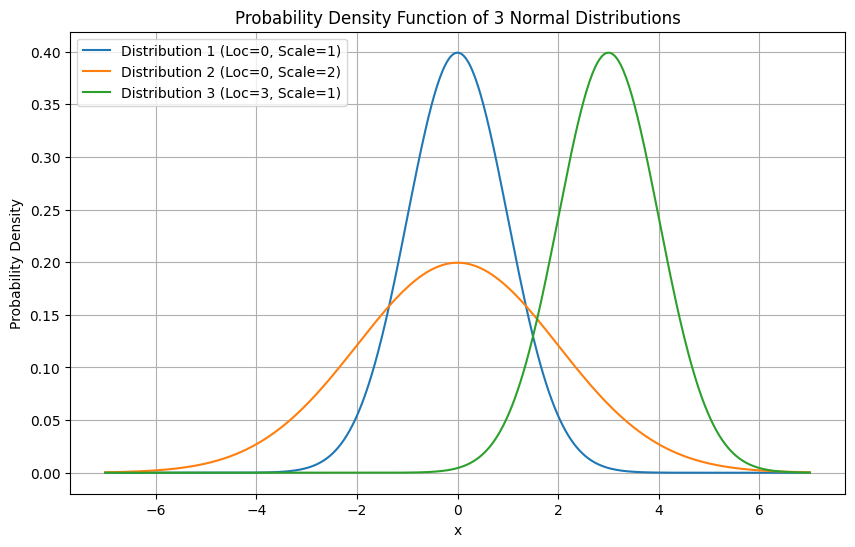

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a range of x values
x = torch.linspace(-7, 7, 500)

# Calculate the log probability density for each distribution
# dist.log_prob(x) will return a tensor of shape (500, 3)
# where each column corresponds to one of the 3 distributions
log_probs = dist.log_prob(x.unsqueeze(-1))

# Convert log probabilities to probabilities (PDF values)
# We need to detach from the computational graph and convert to numpy for plotting
probs = torch.exp(log_probs).detach().numpy()

# Plotting the PDFs
plt.figure(figsize=(10, 6))
for i in range(dist.batch_shape[0]):
    plt.plot(x.numpy(), probs[:, i], label=f'Distribution {i+1} (Loc={dist.loc[i]:.0f}, Scale={dist.scale[i]:.0f})')

plt.title('Probability Density Function of 3 Normal Distributions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import torch

def generate_synthetic_data(w, b, noise=0.01, num_samples=1000):
    """Generates synthetic data for linear regression."""
    X = torch.randn(num_samples, len(w))
    actual_noise = torch.randn(num_samples, 1) * noise
    y = torch.matmul(X, w.reshape((-1, 1))) + b + actual_noise
    return X, y

# Example usage to meet the specified dimensions and sample count:
true_w = torch.tensor([2.0, -3.4]) # 2-dimensional features
true_b = 4.2
features, labels = generate_synthetic_data(true_w, true_b, num_samples=1000)

print("Features (X) shape:", features.shape)
print("Labels (y) shape:", labels.shape)
print("First 5 features:\n", features[:5])
print("First 5 labels:\n", labels[:5])

Features (X) shape: torch.Size([1000, 2])
Labels (y) shape: torch.Size([1000, 1])
First 5 features:
 tensor([[ 0.7460,  0.0327],
        [-0.6847, -1.5276],
        [-0.4141, -0.2562],
        [ 0.6048,  0.8691],
        [ 1.1084, -0.6661]])
First 5 labels:
 tensor([[5.5772],
        [8.0108],
        [4.2221],
        [2.4610],
        [8.6884]])


In [10]:
features.shape

torch.Size([1000, 2])

In [11]:
features.unsqueeze(0)

tensor([[[ 0.7460,  0.0327],
         [-0.6847, -1.5276],
         [-0.4141, -0.2562],
         ...,
         [-0.5363, -1.4274],
         [-0.7068,  1.3714],
         [ 0.2556, -0.4381]]])

In [12]:
from torch.utils.data import Dataset, DataLoader

In [13]:
class SampleDataset(Dataset):
  def __init__(self,X,y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
     return self.X[index], self.y[index]

In [14]:
features[:,0].shape

torch.Size([1000])

In [15]:
dataset = SampleDataset(features,labels)

In [16]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,       # randomize order every epoch
    num_workers=2       # parallel data loading
)

In [17]:
w = torch.randn(1)
b = torch.randn(1)
lr = 0.001

In [18]:
for epoch in range(50):
    for X_batch, y_batch in loader:

      '''Forward pass here wis simply a number
      but because of broadcasting the same
      scalar or tensor is applied to the entire lenth'''
      y_pred = X_batch * w + b
      error = y_pred - y_batch                        # pure error (32,1)
      mse_loss = (error ** 2).mean()
      reg_loss = 0.8 * (w ** 2)                      # regularization on w only
      loss = mse_loss + reg_loss
      # MLE for regression is MSE
      # mean is for sample
      # gradients (manual)
      dw = (2 * error * X_batch).mean() + 2*w
      db = (2 * error).mean()

      # update
      w -= lr * dw
      b -= lr * db
    if epoch % 10 == 0:
      print(f'Epoch {epoch} | Loss: {loss.item():.4f} | w: {w.item():.4f} | b: {b.item():.4f}')

Epoch 0 | Loss: 24.3613 | w: 0.2919 | b: 1.0026
Epoch 10 | Loss: 11.2207 | w: -0.1169 | b: 2.4306
Epoch 20 | Loss: 13.0552 | w: -0.2429 | b: 3.1945
Epoch 30 | Loss: 22.6807 | w: -0.2957 | b: 3.6009
Epoch 40 | Loss: 21.0829 | w: -0.3143 | b: 3.8140
